## LATIHAN

Decision Tree

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score

# Membaca file iris.csv
iris = pd.read_csv('Iris.csv')

# Melihat informasi dataset
iris.info()

# Melihat informasi dataset pada 5 baris pertama
print(iris.head())

# Menghilangkan kolom yang tidak penting
if 'Id' in iris.columns:
    iris.drop('Id', axis=1, inplace=True)

# Memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = iris['Species']

# Membagi dataset menjadi data latih & data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)

# Membuat model Decision Tree
tree_model = DecisionTreeClassifier()

# Melatih model dengan menggunakan data latih
tree_model.fit(X_train, y_train)

# Evaluasi Model
y_pred = tree_model.predict(X_test)
acc_score = round(accuracy_score(y_test, y_pred), 3)
print('Accuracy: ', acc_score)

# Prediksi model dengan DataFrame agar tidak memicu UserWarning
sample_data = pd.DataFrame([[6.2, 3.4, 5.4, 2.3]], columns=X.columns)
print('Hasil Prediksi:', tree_model.predict(sample_data)[0])

# Export visualisasi Decision Tree ke file .dot
export_graphviz(
    tree_model,
    out_file="iris_tree.dot",
    feature_names=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    rounded=True,
    filled=True
)

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa
Accuracy:  0.933
Hasil Prediksi: Ir

Linear Regression

Jumlah kamar: 6
Prediksi harga kamar: 102110.16949152542

Jumlah kamar: 7
Prediksi harga kamar: 119542.37288135593

Akurasi Model (R²): 0.9878112525414624


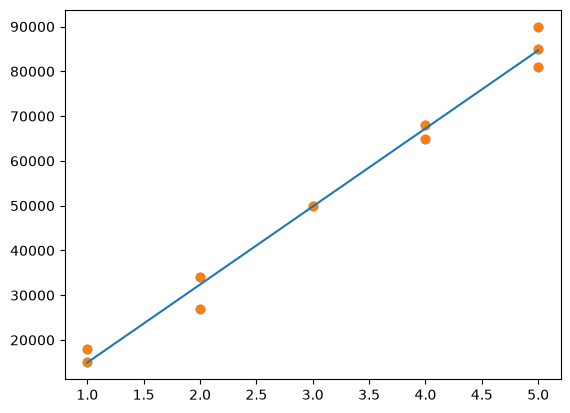

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# buat data jumlah kamar
bedrooms = np.array([1, 1, 2, 2, 3, 4, 4, 5, 5, 5])

# data harga rumah (asumsi dalam dollar)
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000, 85000, 90000])

# menampilkan scatter plot dari dataset
%matplotlib inline
plt.scatter(bedrooms, house_price)

# latih model dengan Linear Regression
bedrooms = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms, house_price)

# menampilkan plot hubungan antara jumlah kamar dengan harga rumah
plt.scatter(bedrooms, house_price)
plt.plot(bedrooms, linreg.predict(bedrooms))

# Data testing (Jumlah kamar yang ingin diprediksi harganya)
X_test = np.array([[6], [7]])

# Melakukan prediksi harga kamar
y_pred = linreg.predict(X_test)

# Menampilkan hasil prediksi
for i in range(len(X_test)):
    print("Jumlah kamar:", X_test[i][0])
    print("Prediksi harga kamar:", y_pred[i])
    print()

# Uji akurasi model pada data latih (R² Score)
print("Akurasi Model (R²):", linreg.score(bedrooms, house_price))

Logistic Regression

In [3]:
import pandas as pd

# membaca dataset dan mengubahnya menjadi dataframe
df = pd.read_csv('Social_Network_Ads.csv')

# melihat 5 baris pertama data
df.head()

# melihat informasi dataset
df.info()

# drop kolom yang tidak diperlukan
data = df.drop(columns=['User ID'])

# jalankan proses one-hot encoding dengan pd.get_dummies()
data = pd.get_dummies(data)
data

# pisahkan atribut dan label
predictions = ['Age', 'EstimatedSalary', 'Gender_Female', 'Gender_Male']
X = data[predictions]
y = data['Purchased']

# lakukan normalisasi terhadap data yang kita miliki
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
scaled_data = scaler.transform(X)
scaled_data = pd.DataFrame(scaled_data, columns=X.columns)
scaled_data.head()

from sklearn.model_selection import train_test_split

# bagi data menjadi train dan test untuk setiap atribut dan label
X_train, X_test, y_train, y_test = train_test_split(scaled_data, y, test_size=0.2, random_state=1)

from sklearn import linear_model

# latih model dengan fungsi fit
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

# uji akurasi model
model.score(X_test, y_test)

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB


0.825

##TUGAS PRAKTIKUM

Tugas 1: Memprediksi Transaksi Konsumen (Decision Tree & Logistic Regression)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Membaca dataset iklan_sosmed.csv dengan pemisah titik koma
df_sosmed = pd.read_csv('iklan_sosmed.csv', sep=';')

# 2. Preprocessing Data
# Menghilangkan kolom ID karena tidak relevan untuk prediksi
data_sosmed = df_sosmed.drop(columns=['ID'])

# One-Hot Encoding untuk kolom kategorikal Jenis_Kelamin
data_sosmed = pd.get_dummies(data_sosmed, columns=['Jenis_Kelamin'])

# Memisahkan Atribut (X) dan Label (y)
X_sosmed = data_sosmed.drop(columns=['Transaksi'])
y_sosmed = data_sosmed['Transaksi']

# Normalisasi / Standarisasi Atribut
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sosmed)
X_scaled = pd.DataFrame(X_scaled, columns=X_sosmed.columns)

# 3. Membagi data menjadi Train Set (80%) dan Test Set (20%)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_scaled, y_sosmed, test_size=0.2, random_state=1
)

# 4. Pelatihan & Evaluasi Baseline Model Logistic Regression
logreg_model = LogisticRegression(random_state=1)
logreg_model.fit(X_train_s, y_train_s)
acc_logreg_base = logreg_model.score(X_test_s, y_test_s)

# 5. Pelatihan & Evaluasi Baseline Model Decision Tree
dtree_model = DecisionTreeClassifier(random_state=1)
dtree_model.fit(X_train_s, y_train_s)
acc_dtree_base = dtree_model.score(X_test_s, y_test_s)

print(f"Akurasi Awal Logistic Regression: {acc_logreg_base * 100:.2f}%")
print(f"Akurasi Awal Decision Tree       : {acc_dtree_base * 100:.2f}%")

Akurasi Awal Logistic Regression: 82.50%
Akurasi Awal Decision Tree       : 78.75%


Tugas 2: Memprediksi Gaji Pegawai Berdasarkan Masa Kerja (Linear Regression)

Skor Akurasi (R² Score) Linear Regression: 76.17%


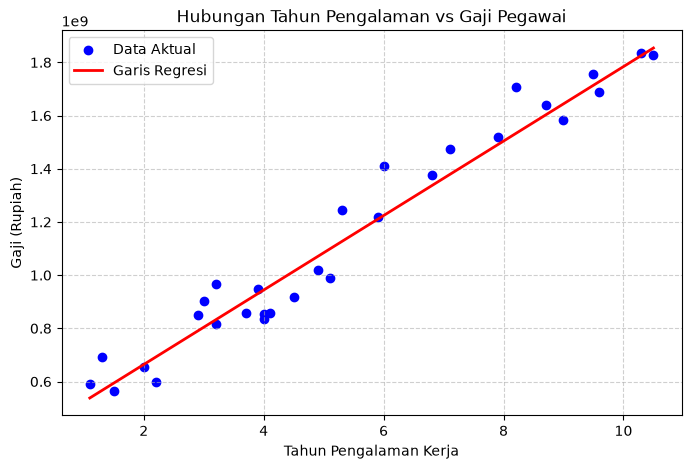

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Membaca dataset Data_Gaji.csv
df_gaji = pd.read_csv('Data_Gaji.csv', sep=';')

# Memisahkan Atribut (Tahun_Pengalaman) dan Label (Gaji)
X_gaji = df_gaji[['Tahun_Pengalaman']]
y_gaji = df_gaji['Gaji']

# 2. Membagi data latih dan data uji
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_gaji, y_gaji, test_size=0.2, random_state=1
)

# 3. Melatih Model Linear Regression
linreg_gaji = LinearRegression()
linreg_gaji.fit(X_train_g, y_train_g)

# 4. Prediksi dan Evaluasi Model
y_pred_g = linreg_gaji.predict(X_test_g)
r2_score_gaji = linreg_gaji.score(X_test_g, y_test_g)

print(f"Skor Akurasi (R² Score) Linear Regression: {r2_score_gaji * 100:.2f}%")

# Visualisasi Garis Regresi
plt.figure(figsize=(8, 5))
plt.scatter(X_gaji, y_gaji, color='blue', label='Data Aktual')
plt.plot(X_gaji, linreg_gaji.predict(X_gaji), color='red', linewidth=2, label='Garis Regresi')
plt.title('Hubungan Tahun Pengalaman vs Gaji Pegawai', fontsize=12)
plt.xlabel('Tahun Pengalaman Kerja', fontsize=10)
plt.ylabel('Gaji (Rupiah)', fontsize=10)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Tugas 3 & 4: Perbandingan Akurasi & Parameter Tuning (GridSearchCV)

In [6]:
from sklearn.model_selection import GridSearchCV

# 1. Hyperparameter Tuning untuk Logistic Regression
param_grid_logreg = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}

grid_logreg = GridSearchCV(
    LogisticRegression(random_state=1),
    param_grid_logreg,
    cv=5,
    scoring='accuracy'
)
grid_logreg.fit(X_train_s, y_train_s)

best_logreg = grid_logreg.best_estimator_
acc_logreg_tuned = best_logreg.score(X_test_s, y_test_s)


# 2. Hyperparameter Tuning untuk Decision Tree
param_grid_dtree = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_dtree = GridSearchCV(
    DecisionTreeClassifier(random_state=1),
    param_grid_dtree,
    cv=5,
    scoring='accuracy'
)
grid_dtree.fit(X_train_s, y_train_s)

best_dtree = grid_dtree.best_estimator_
acc_dtree_tuned = best_dtree.score(X_test_s, y_test_s)


# 3. Menampilkan Hasil Perbandingan Akurasi
print("=== PERBANDINGAN AKURASI ===")
print(f"Logistic Regression (Awal)  : {acc_logreg_base * 100:.2f}%")
print(f"Logistic Regression (Tuned) : {acc_logreg_tuned * 100:.2f}%  --> Best Params: {grid_logreg.best_params_}")
print("-" * 50)
print(f"Decision Tree (Awal)        : {acc_dtree_base * 100:.2f}%")
print(f"Decision Tree (Tuned)       : {acc_dtree_tuned * 100:.2f}%  --> Best Params: {grid_dtree.best_params_}")

=== PERBANDINGAN AKURASI ===
Logistic Regression (Awal)  : 82.50%
Logistic Regression (Tuned) : 83.75%  --> Best Params: {'C': 0.1, 'solver': 'lbfgs'}
--------------------------------------------------
Decision Tree (Awal)        : 78.75%
Decision Tree (Tuned)       : 86.25%  --> Best Params: {'criterion': 'gini', 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
